In [1]:
# import all the dependencies
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:

# create a state that means create a class not a function
class BatsmanSummary(TypedDict):

#inputs to the graph
    runs: int
    balls: int
    sixes: int
    fours: int

# output of the graph  
    strike_rate: float
    bpb: float
    boundary_percent: float
    summary: str


In [3]:
# create/call the graph
graph = StateGraph(BatsmanSummary)

In [4]:

# define a function to calculate strike rate 
def strike_rate(state: BatsmanSummary):
    runs = state['runs']
    balls = state['balls']

    sr = (runs / balls) * 100 if balls > 0 else 0

    return {'strike_rate': sr}


In [5]:
# define a function to calculate Boundary per balls
def boundary_per_balls(state: BatsmanSummary):
    balls = state['balls']
    boundaries = state['fours'] + state['sixes']

    bpb = balls / boundaries if boundaries > 0 else 0

    return {'bpb': bpb}

In [6]:
# define a function to calculate Boundary Percentage
def boundary_percentage(state: BatsmanSummary):
    runs = state['runs']
    boundary_runs = (state['fours'] * 4) + (state['sixes'] * 6)

    bp = (boundary_runs / runs) * 100 if runs > 0 else 0

    return {'boundary_percent': bp}


In [7]:
#define a function to calculate Summary
def summary(state: BatsmanSummary):
    
    return {
        'summary': f"""
Strike Rate is - {state['strike_rate']}

Balls per boundary - {state['bpb']}

Boundary percentage - {state['boundary_percent']}
"""
    }


In [8]:
# create and add node
graph.add_node('strike_rate', strike_rate)
graph.add_node('bpb', boundary_per_balls)
graph.add_node('boundarypercent', boundary_percentage)
graph.add_node('summary', summary)

In [9]:
# create and add edges 
graph.add_edge(START,'strike_rate')
graph.add_edge('strike_rate','summary')
graph.add_edge('summary',END)

# create and add edges
graph.add_edge(START,'bpb')
graph.add_edge('bpb','summary')
graph.add_edge('summary',END)

# create and add edges
graph.add_edge(START,'boundarypercent')
graph.add_edge('boundarypercent','summary')
graph.add_edge('summary',END)



In [10]:
# compile the workflow
workflow = graph.compile()

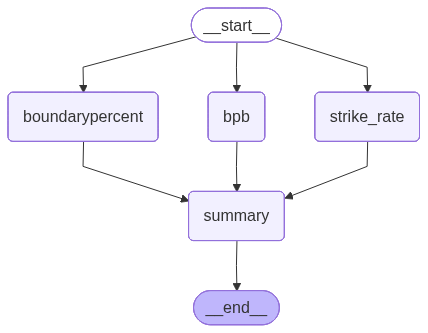

In [11]:
# invoke the workflow
workflow

In [12]:
# invoke the graph 

initial_state = {
    'runs' : 100,
    'balls' : 50,
    'sixes' : 4,
    'fours' : 6
}

final_state = workflow.invoke(initial_state)
print (final_state)

{'runs': 100, 'balls': 50, 'sixes': 4, 'fours': 6, 'strike_rate': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': '\nStrike Rate is - 200.0\n\nBalls per boundary - 5.0\n\nBoundary percentage - 48.0\n'}


In [ ]:
# {'runs': 100, 
#  'balls': 50, 
#  'sixes': 4, 
#  'fours': 6, 
#  'strike_rate': 200.0, 
#  'bpb': 5.0, 
#  'boundary_percent': 48.0, 
#  'summary': '\nStrike Rate is - 200.0\nBalls per boundary - 5.0\n\nBoundary percentage - 48.0\n'}